# Zhang 2023 brand 2 and EVBattery dataset 3 are the same fleet

**Question.** Two releases from the same Tsinghua group, Zhang 2023 (fault detection) and EVBattery (capacity estimation), both contain an archive of 49 vehicles: Zhang's `battery_brand2` and EVBattery's `battery_dataset3`. Are these the same cars under different numbers?

**Why it matters.** If they are, counting both would double-count those vehicles in the collection totals.

**How this notebook answers it, in plain terms.**
1. List the vehicles in each archive.
2. Give every charging snippet a "fingerprint" built from its recorded values. Two snippets with the same fingerprint are the same recording.
3. Count how many fingerprints each Zhang car shares with each EVBattery car.
4. Call a pair confirmed only when one partner clearly wins.
5. Check that the fault labels agree for the confirmed pairs.
6. Look at one shared snippet side by side.
7. Check that the other archives share nothing, as a control.

All data is read through the repository's loaders (`fielddata.zhang2023`, `fielddata.evbattery`). Nothing is copied from earlier results except in step 4, where the committed pair list is checked against what this notebook finds.

In [1]:
import collections, hashlib, json, pickle, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))   # lets the notebook find the fielddata package in this repository
from fielddata.loaders import zhang2023, evbattery
Z_ARCH, E_ARCH = "battery_brand2.tar.gz", "battery_dataset3.tar.gz"
HIGHLIGHT, CONTEXT = "#5b3f9e", "#b8b8b8"   # one highlighted series, gray context
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False})

## Step 1. The two archives each hold 49 vehicles

**Why:** a shared fleet must at least be the same size. **What to look for:** the same vehicle count and a similar label mix. A label of 1 means the authors marked the car as faulty.

In [2]:
zs = zhang2023.systems().query("archive == @Z_ARCH")
es = evbattery.systems().query("archive == @E_ARCH")
pd.DataFrame({
    "vehicles in label file": [len(zs), len(es)],
    "vehicles with snippets": [int((zs.snippets > 0).sum()), int((es.snippets > 0).sum())],
    "car numbers": [f"{zs.car.min()} to {zs.car.max()}", f"{es.car.min()} to {es.car.max()}"],
    "labelled faulty (label 1)": [int((zs.label == 1).sum()), int((es.label == 1).sum())],
    "snippets": [int(zs.snippets.sum()), int(es.snippets.sum())],
}, index=["zhang2023 brand 2", "evbattery dataset 3"])

,vehicles in label file,vehicles with snippets,car numbers,labelled faulty (label 1),snippets
zhang2023 brand 2,50,49,201 to 250,16,194245
evbattery dataset 3,50,49,500 to 549,16,176327


**Result:**
- Each label file lists 50 cars, but one car in each has no snippets. So 49 cars carry data on each side.
- Both have 16 cars labelled faulty.
- The car numbers don't overlap (201-250 vs 500-549), so numbers alone can't pair them. The pairing has to come from the data.

## Step 2. Fingerprint every snippet

**Why:** a snippet is 128 rows of one charging session. If two releases contain the same recording, its values are identical, whatever car number it carries.

Three fingerprints per snippet, so a match never rests on one choice:
- **exact:** current, SOC, max and min cell voltage, max and min temperature, rounded to 0.01. Pack voltage is left out because the two releases scale it differently (see step 6).
- **cell voltage only:** max and min cell voltage, rounded to 0.001.
- **current and SOC only:** rounded to 0.1.

This reads each archive once, about a minute each.

In [3]:
def fingerprints(loader, archive):
    exact, volt, cur, st = (collections.defaultdict(set) for _ in range(4))
    examples = {}
    for _, a, meta in loader.iter_snippets(archive):
        car = int(meta["car"])
        h = hashlib.md5(np.round(a[:, 1:7], 2).tobytes()).hexdigest()[:12]
        exact[car].add(h); examples.setdefault((h, car), (a, str(meta.get("charge_segment"))))
        volt[car].add(hashlib.md5(np.round(a[:, 3:5], 3).tobytes()).hexdigest()[:12])
        cur[car].add(hashlib.md5(np.round(a[:, 1:3], 1).tobytes()).hexdigest()[:12])
        g = hashlib.md5(np.round(a[:, [2, 5, 6]], 0).tobytes()).hexdigest()[:12]
        st[car].add(g); examples.setdefault(("st", g, car), a)
        examples.setdefault(("seg", g, car), str(meta.get("charge_segment")))
    return {"exact": exact, "volt": volt, "cur": cur, "st": st}, examples

zf, zex = fingerprints(zhang2023, Z_ARCH)
ef, eex = fingerprints(evbattery, E_ARCH)
shared = set().union(*zf["exact"].values()) & set().union(*ef["exact"].values())
print(f"identical snippets found in both archives: {len(shared):,}")

identical snippets found in both archives: 2,616


**Result:**
- 2,616 snippets have the same fingerprint in both releases, the same count the Windows machine found.
- They match after rounding, not bit for bit. Zhang stores cell voltage in steps of 1/64 V and EVBattery in millivolts, so the same reading can differ by up to about 0.01 V. Current, SOC and temperature agree exactly.

## Step 3. Which car shares snippets with which

**Why:** if the fleets are the same, each Zhang car should share snippets with one EVBattery car and almost none with the others.

**A caution first.** Some fingerprints occur in several cars on the same side, for example a flat snippet at 100 % SOC that happens to read the same in two cars. Such a fingerprint says nothing about which car is which, so only fingerprints owned by **one car on each side** are used from here on.

The grid has one row per Zhang car and one column per EVBattery car. A dark cell means many shared snippets. Rows and columns are ordered so each row's best partner sits on the diagonal.

shared fingerprints: 2,616; owned by one car on each side: 1,835


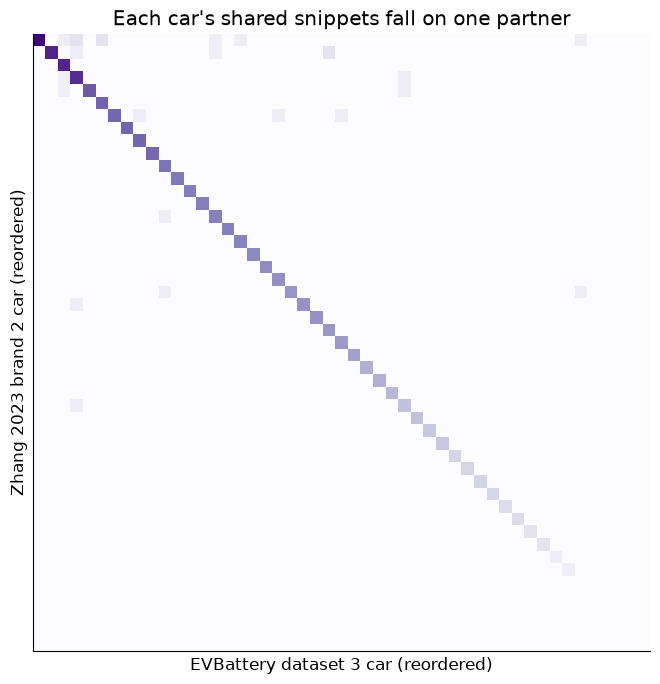

In [4]:
def owners(fp):
    o = collections.defaultdict(set)
    for car, hs in fp.items():
        for h in hs: o[h].add(car)
    return o

zo, eo = owners(zf["exact"]), owners(ef["exact"])
zcars, ecars = sorted(zf["exact"]), sorted(ef["exact"])
both = set(zo) & set(eo)
unique = [h for h in both if len(zo[h]) == 1 and len(eo[h]) == 1]
print(f"shared fingerprints: {len(both):,}; owned by one car on each side: {len(unique):,}")
M = pd.DataFrame(0, index=zcars, columns=ecars)
for h in unique:
    M.loc[next(iter(zo[h])), next(iter(eo[h]))] += 1
rows = list(M.sum(axis=1).sort_values(ascending=False).index)
order = list(dict.fromkeys([M.loc[z].idxmax() for z in rows if M.loc[z].max() > 0]))
order += [e for e in ecars if e not in order]
G = M.loc[rows, order]

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(np.log1p(G.values), cmap="Purples", aspect="equal")
ax.set_xlabel("EVBattery dataset 3 car (reordered)"); ax.set_ylabel("Zhang 2023 brand 2 car (reordered)")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Each car's shared snippets fall on one partner")
plt.tight_layout(); plt.show()

**Result:**
- The dark cells form a clean diagonal: each Zhang car shares its snippets with one EVBattery car.
- Off the diagonal, cells are empty or very faint.
- The bottom rows are cars with few or no shared snippets. Step 4 deals with those.

## Step 4. Confirm pairs one to one

**Rule, in plain terms.**
- Every fingerprint that belongs to exactly one car on each side counts as one vote for that pairing. All three fingerprints vote.
- A pair is **confirmed** when its votes are at least three times the runner-up's. In a first pass the pair also needs at least 10 votes.
- In a second pass, a car with fewer votes can still be confirmed if its partner is not already taken and the three-times rule holds.

This is the same rule as `scripts/facts/_overlap_scan.py refine`. It is written out again here so you can read it.

In [5]:
votes = collections.defaultdict(collections.Counter)
for kind in ("exact", "volt", "cur"):
    oz, oe = owners(zf[kind]), owners(ef[kind])
    for h in set(oz) & set(oe):
        if len(oz[h]) == 1 and len(oe[h]) == 1:
            votes[next(iter(oz[h]))][next(iter(oe[h]))] += 1
best = {}
for z, c in votes.items():
    r = c.most_common(2)
    best[z] = (r[0][0], r[0][1], r[1][1] if len(r) > 1 else 0)
pairs = {z: b for z, b in best.items() if b[1] >= 3 * max(1, b[2]) and b[1] >= 10}
taken = {b[0] for b in pairs.values()}
for z, b in best.items():
    if z not in pairs and b[0] not in taken and b[1] >= 3 * max(1, b[2]):
        pairs[z] = b; taken.add(b[0])

committed = json.loads((ROOT / "reports/facts/_cache/zhang2023_evbattery_pairs.json").read_text())["pairs"]
mine = {str(z): b[0] for z, b in pairs.items()}
print(f"confirmed pairs: {len(pairs)}")
print(f"all {len(mine)} agree with the committed pair list: {all(committed.get(k) == v for k, v in mine.items())}")
print(f"committed pairs added later by tolerance matching (step 5c): {sorted(set(committed) - set(mine))}")
table = pd.DataFrame([(z, b[0], b[1], b[2]) for z, b in sorted(pairs.items())],
                     columns=["zhang car", "evbattery car", "votes", "runner-up votes"])
table.describe().loc[["min", "50%", "max"], ["votes", "runner-up votes"]]

confirmed pairs: 44
all 44 agree with the committed pair list: True
committed pairs added later by tolerance matching (step 5c): ['226', '229', '231', '232', '250']


,votes,runner-up votes
min,3.0,0.0
50%,27.5,1.0
max,398.0,17.0


**Result:**
- 44 pairs are confirmed by this rule, and all 44 agree with the committed list.
- The committed list also includes the 5 pairs found in step 5c.
- A typical pair has about 28 votes against 1 for its runner-up.
- The weakest pair rests on only 3 votes against 0. A few pairs are therefore thin on their own. Steps 5 and 5b add independent support.

### The five cars on each side that the strict rule leaves unconfirmed

**Why look:** to see whether they are missed matches or simply have too little data. Steps 4b and 5c come back to them.

In [6]:
zu = [z for z in zcars if z not in pairs]; eu = [e for e in ecars if e not in taken]
unconf = pd.DataFrame({
    "zhang car": zu,
    "zhang snippets": [len(zf["exact"][z]) for z in zu],
    "best votes": [best.get(z, (None, 0, 0))[1] for z in zu],
})
print("unconfirmed evbattery cars:", eu, "| their snippets:", [len(ef["exact"][e]) for e in eu])
unconf

unconfirmed evbattery cars: [531, 546, 547, 548, 549] | their snippets: [384, 6, 24, 115, 684]


,zhang car,zhang snippets,best votes
0,226,56,1
1,229,15,1
2,231,16,1
3,232,5,0
4,250,5,0


**Result:**
- The five Zhang cars have only 5 to 56 snippets each and 0 or 1 votes.
- Two of the five EVBattery cars have hundreds of snippets, but almost none of them match Zhang's archive under the strict fingerprint.
- So the strict rule can't pair these cars either way. Step 5c resolves them with a more tolerant comparison.

## Step 4b. A second, independent fingerprint gives the same pairs

**Why:** the exact fingerprint has a weak spot. Values are rounded to 0.01 before comparing. A reading that differs by half a millivolt between the releases can round to different sides on one of 128 rows, and then the whole snippet no longer matches. So the exact fingerprint mostly catches flat snippets (no current, often 100 % SOC) and misses charging snippets.

This step uses a fingerprint the two storage formats can't disturb: **SOC and the two temperatures, rounded to whole numbers**. Only fingerprints owned by one car on each side count, as before.

In [7]:
oz, oe = owners(zf["st"]), owners(ef["st"])
st_unique = [h for h in set(oz) & set(oe) if len(oz[h]) == 1 and len(oe[h]) == 1]
st_votes = collections.defaultdict(collections.Counter)
for h in st_unique:
    st_votes[next(iter(oz[h]))][next(iter(oe[h]))] += 1
st_best = {z: c.most_common(1)[0] for z, c in st_votes.items()}
print(f"snippets matched by SOC and temperature: {len(st_unique):,} (exact fingerprint: {len(unique):,})")
print(f"best partner is the same as step 4 for {sum(st_best.get(z, (None,))[0] == b[0] for z, b in pairs.items())} of {len(pairs)} confirmed pairs")
pd.DataFrame([(z, *st_votes[z].most_common(1)[0]) if z in st_votes else (z, None, 0) for z in zu],
             columns=["unconfirmed zhang car", "best evbattery partner", "votes"])

snippets matched by SOC and temperature: 11,340 (exact fingerprint: 1,835)
best partner is the same as step 4 for 44 of 44 confirmed pairs


,unconfirmed zhang car,best evbattery partner,votes
0,226,531.0,13
1,229,549.0,1
2,231,NaN,0
3,232,547.0,1
4,250,546.0,3


**Result:**
- This fingerprint matches about six times as many snippets, including charging snippets with current flowing.
- It picks the same partner for all 44 confirmed pairs.
- It also points at possible partners for the unconfirmed cars, most clearly Zhang 226 with EVBattery 531 (13 votes, no rival).
- Votes alone can't settle pairs this small, because flat snippets can match by chance. Step 5c settles them.

## Step 5. The fault labels agree

**Why:** if a pair really is one car, both releases should give it the same faulty-or-normal label.

In [8]:
zl = zs.set_index("car").label; el = es.set_index("car").label
agree = sum(zl[z] == el[b[0]] for z, b in pairs.items())
print(f"labels agree in {agree} of {len(pairs)} confirmed pairs")

labels agree in 44 of 44 confirmed pairs


**Result:** all 44 agree. This is a separate check from the fingerprints, and it passes.

## Step 5b. The charging-session numbers agree too

**Why:** each snippet also carries a `charge_segment` number, the authors' index of the charging session it came from. This number was not used in the fingerprint. If the matched snippets are the same recordings, the session numbers should agree.

In [9]:
same_seg = 0
for h in unique:
    z, e = next(iter(zo[h])), next(iter(eo[h]))
    same_seg += zex[(h, z)][1] == eex[(h, e)][1]
print(f"charging-session number agrees on {same_seg:,} of {len(unique):,} matched snippets ({same_seg / len(unique):.0%})")

charging-session number agrees on 1,464 of 1,835 matched snippets (80%)


**Result:**
- Most matched snippets carry the same session number in both releases, even though that number played no part in the matching. That's strong independent evidence the matches are real.
- The rest may be renumbered sessions. They're worth asking the authors about, but they don't change the pairing.
- Mileage is not compared here: the two releases store it on different, inconsistent scales.

## Step 5c. Matching with a tolerance pairs the last five cars

**Why:** hash fingerprints only match when every rounded value is equal. Zhang stores cell voltage in steps of 1/64 V and EVBattery in millivolts, so most charging snippets never hash the same. That's why five cars on each side were left unconfirmed in step 4. Here snippets are compared value by value, allowing for the storage resolution.

**Guarding against chance matches.** Flat snippets can match between different cars by accident. The session number tells these apart, as the first table shows:
- For step 4b matches between confirmed partners, the session number agrees almost always.
- For matches between other cars, it almost never does.
So a tolerance match only counts as evidence when the session number agrees too.

**Rule:** an unconfirmed car is paired when its best partner has at least 3 session-agreeing matches, at least three times any other car's, and the partner is still free. The same rule is in `scripts/facts/_overlap_scan.py tolerance`.

In [10]:
groups = collections.Counter(); agree_n = collections.Counter()
for h in st_unique:
    z, e = next(iter(oz[h])), next(iter(oe[h]))
    if z in zu or e in eu:
        continue
    group = "confirmed partners" if pairs.get(z, (None,))[0] == e else "other cars"
    groups[group] += 1
    agree_n[group] += zex[("seg", h, z)] == eex[("seg", h, e)]
display(pd.DataFrame({"matches": groups, "session number agrees": agree_n}).assign(
    share=lambda d: (d["session number agrees"] / d["matches"]).map("{:.0%}".format)))

cols = [1, 2, 3, 4, 5, 6]
left = [(int(m["car"]), str(m.get("charge_segment")), a[:, cols])
        for _, a, m in zhang2023.iter_snippets(Z_ARCH) if int(m["car"]) in zu]
stack = np.stack([x[2] for x in left])
tol = collections.defaultdict(collections.Counter)
for _, a, m in evbattery.iter_snippets(E_ARCH):
    d = np.abs(stack - a[:, cols])
    hit = ((np.median(d[:, :, 0], axis=1) < 0.5) & (d[:, :, 1].max(axis=1) < 0.6)
           & (np.median(d[:, :, 2], axis=1) < 0.003) & (np.median(d[:, :, 3], axis=1) < 0.003)
           & (d[:, :, 4].max(axis=1) <= 1) & (d[:, :, 5].max(axis=1) <= 1))
    for i in np.where(hit)[0]:
        if left[i][1] == str(m.get("charge_segment")):
            tol[left[i][0]][int(m["car"])] += 1
free, added = set(eu), {}
for z in zu:
    ranked = tol[z].most_common(2)
    partner, n = ranked[0] if ranked else (None, 0)
    rival = ranked[1][1] if len(ranked) > 1 else 0
    ok = n >= 3 and n >= 3 * max(1, rival) and partner in free
    print(f"zhang {z}: best partner evbattery {partner} with {n} session-agreeing matches, next best {rival} -> {'paired' if ok else 'not paired'}")
    if ok:
        added[z] = partner; free.discard(partner)
allpairs = {**{z: b[0] for z, b in pairs.items()}, **added}
print(f"pairs in total: {len(allpairs)}; same as the committed list: {({str(z): e for z, e in allpairs.items()}) == committed}")
print(f"fault labels agree in {sum(zl[z] == el[e] for z, e in allpairs.items())} of {len(allpairs)}; labelled faulty: {int(sum(zl[z] == 1 for z in allpairs))}")

,matches,session number agrees,share
confirmed partners,10655,10358,97%
other cars,666,2,0%


zhang 226: best partner evbattery 531 with 261 session-agreeing matches, next best 0 -> paired
zhang 229: best partner evbattery 549 with 173 session-agreeing matches, next best 0 -> paired
zhang 231: best partner evbattery 548 with 64 session-agreeing matches, next best 0 -> paired
zhang 232: best partner evbattery 547 with 26 session-agreeing matches, next best 0 -> paired
zhang 250: best partner evbattery 546 with 26 session-agreeing matches, next best 0 -> paired
pairs in total: 49; same as the committed list: True
fault labels agree in 49 of 49; labelled faulty: 16


**Result:**
- The session-number test separates real matches from chance ones clearly.
- Each of the five leftover Zhang cars matches exactly one EVBattery car, many times over, with no rival.
- That brings the total to 49 pairs, the whole fleet, the same as the committed list. Fault labels agree for all 49, and 16 of them are labelled faulty.

## Step 6. One shared snippet, side by side

**Why:** to see what a match looks like. Of the snippets matched in step 4b, the one with the largest swing in current is picked and drawn from each release.
- Left: maximum cell voltage. The two traces follow each other. Zhang's sits on a coarser 1/64 V grid.
- Right: pack voltage, which the two releases store on different scales. That's why pack voltage was left out of the fingerprint.

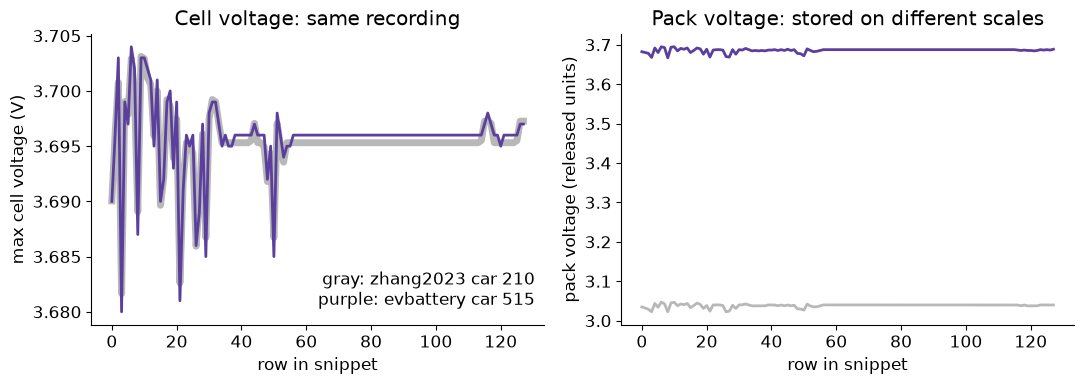

,typical (median) difference,largest difference
current (A),0.0000,41.6000
SOC (%),0.0000,0.0469
max cell V,0.0007,0.0022
min cell V,0.0009,0.0027
max T (C),0.0000,0.1000
min T (C),0.0000,0.1000


In [11]:
oz, oe = owners(zf["st"]), owners(ef["st"])
h = max(st_unique, key=lambda k: np.ptp(zex[("st", k, next(iter(oz[k])))][:, 1]))
z0, e0 = next(iter(oz[h])), next(iter(oe[h]))
a, b = zex[("st", h, z0)], eex[("st", h, e0)]
fig, (l, r) = plt.subplots(1, 2, figsize=(11, 4))
l.plot(a[:, 3], color=CONTEXT, lw=5); l.plot(b[:, 3], color=HIGHLIGHT, lw=2)
l.set_title("Cell voltage: same recording"); l.set_xlabel("row in snippet"); l.set_ylabel("max cell voltage (V)")
l.text(0.98, 0.05, f"gray: zhang2023 car {z0}\npurple: evbattery car {e0}", transform=l.transAxes, va="bottom", ha="right")
r.plot(a[:, 0], color=CONTEXT, lw=2); r.plot(b[:, 0], color=HIGHLIGHT, lw=2)
r.set_title("Pack voltage: stored on different scales"); r.set_xlabel("row in snippet"); r.set_ylabel("pack voltage (released units)")
plt.tight_layout(); plt.show()
diff = pd.DataFrame({"typical (median) difference": np.median(np.abs(a[:, 1:7] - b[:, 1:7]), axis=0),
                     "largest difference": np.abs(a[:, 1:7] - b[:, 1:7]).max(axis=0)},
                    index=["current (A)", "SOC (%)", "max cell V", "min cell V", "max T (C)", "min T (C)"]).round(4)
diff

**Result:**
- During a real charge, the two cell-voltage traces lie on top of each other, within the storage resolution.
- The table shows the typical and largest row-by-row differences. Typical differences are at the storage resolution. A few rows differ more, most likely a one-row timing offset in a fast current change.
- Pack voltage has the same shape at a different level, which shows that one release rescaled that column.

## Step 7. Control: the other archives share nothing

**Why:** if the fingerprint were too loose, unrelated archives would also show matches. This step uses the per-archive fingerprints written by `scripts/facts/_overlap_scan.py sig`, which reads the same loaders. It skips with a message if they haven't been made.

In [12]:
sig = ROOT / "data" / "extracts" / "overlap"
if not sig.is_dir():
    print("Run scripts/facts/_overlap_scan.py sig ... for all six archives first.")
else:
    def allh(f):
        return set().union(*pickle.load(open(f, "rb")).values())
    Z = {f.name.split("__")[1].split(".")[0]: allh(f) for f in sorted(sig.glob("zhang2023__*.pkl"))}
    E = {f.name.split("__")[1].split(".")[0]: allh(f) for f in sorted(sig.glob("evbattery__*.pkl"))}
    display(pd.DataFrame({e: {z: len(Z[z] & E[e]) for z in Z} for e in E}))

,battery_dataset1,battery_dataset2,battery_dataset3
battery_brand1,0,0,0
battery_brand2,0,0,2616
battery_brand3,0,0,0


**Result:** only brand 2 against dataset 3 shares snippets. Every other combination shows 0.

## Conclusion

- Zhang 2023 brand 2 and EVBattery dataset 3 are one fleet of 49 vehicles released twice, under different car numbers.
- All 49 cars pair one to one. 44 pass the strict fingerprint rule, and a second independent fingerprint picks the same 44 partners.
- The last 5 are paired by tolerant matching backed by agreeing session numbers.
- Fault labels agree for all 49.
- No other archives overlap.
- The collection totals count these 49 vehicles once.